Detected data types: KE, PE, DKE
Number of time steps: 202


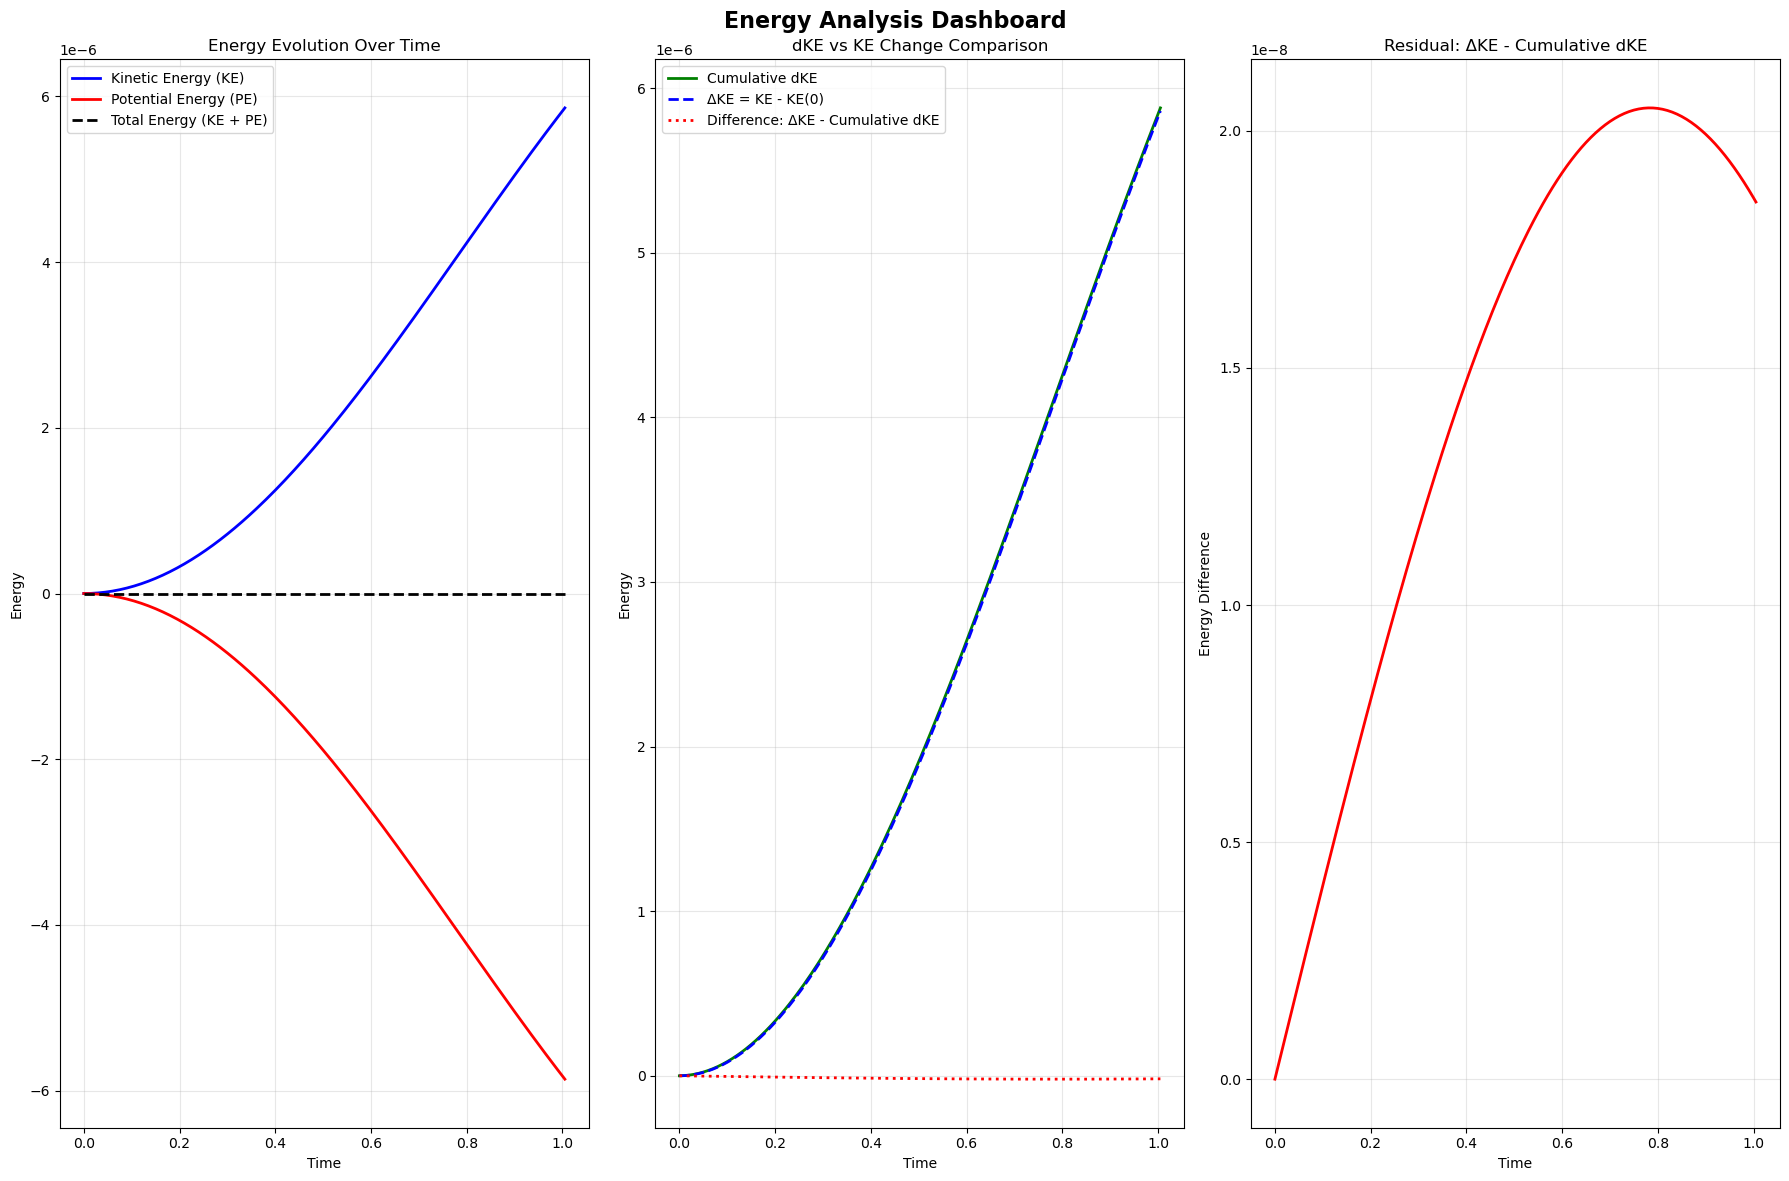


ENERGY ANALYSIS SUMMARY
Initial KE: 0.000000e+00
Final KE: 5.861056e-06
KE Change: 5.861056e-06
Cumulative dKE: 5.879556e-06
Residual (ΔKE - Cum.dKE): -1.849996e-08
Initial PE: 0.000000e+00
Final PE: -5.861055e-06
PE Change: -5.861055e-06
Total Energy Change: 5.166378e-13
DETAILED ENERGY EVOLUTION TABLE
Total time steps: 202


,Time,KE,PE,Cumul. dKE,Total Energy,ΔKE,Residual
0,0.0000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,0.0050,2.056168e-10,-2.056155e-10,4.112284e-10,1.285105e-15,2.056168e-10,-2.056116e-10
2,0.0100,8.224516e-10,-8.224465e-10,1.233647e-09,5.140492e-15,8.224516e-10,-4.111950e-10
3,0.0150,1.850443e-09,-1.850435e-09,2.467172e-09,7.710900e-15,1.850443e-09,-6.167295e-10
4,0.0200,3.289488e-09,-3.289477e-09,4.111682e-09,1.028123e-14,3.289488e-09,-8.221946e-10
5,0.0250,5.139442e-09,-5.139429e-09,6.167012e-09,1.285157e-14,5.139442e-09,-1.027570e-09
6,0.0300,7.400122e-09,-7.400106e-09,8.632956e-09,1.542191e-14,7.400122e-09,-1.232835e-09
7,0.0350,1.007130e-08,-1.007128e-08,1.150927e-08,1.799224e-14,1.007130e-08,-1.437968e-09
8,0.0400,1.315271e-08,-1.315269e-08,1.479566e-08,2.056258e-14,1.315271e-08,-1.642950e-09
9,0.0450,1.664404e-08,-1.664402e-08,1.849180e-08,2.313292e-14,1.664404e-08,-1.847761e-09


In [ ]:
# read especData.dat in the output
import numpy as np
import pandas as pd
from IPython.display import display, HTML
import matplotlib.pyplot as plt

# Load the data from the file
with open('../../output/especData.dat', 'r') as f:
    lines = f.readlines()

# Process the data
i = 0
times = []
ke_data = []
pe_data = []
dke_data = []
has_pe2 = False
while i < len(lines):

    current_set = {}
    set_start = i
    
    while i < len(lines):
        line = lines[i].strip()
        if line:
            parts = line.split()
            label = parts[0].rstrip(':').upper()
            time_val = float(parts[1])
            data_vals = [float(x) for x in parts[2:]]
            
            current_set[label] = {'time': time_val, 'data': data_vals}
            i += 1
            
            # Check if we have a complete set (at minimum KE, PE, DKE)
            if 'KE' in current_set and 'PE' in current_set and 'DKE' in current_set:
                # Check if there's a PE2 in the next line
                if i < len(lines):
                    next_line = lines[i].strip()
                    if next_line and next_line.split()[0].rstrip(':').upper() == 'PE2':
                        continue  # Read PE2 as well
                break
        else:
            i += 1
    
    # Store the data from current set
    if 'KE' in current_set and 'PE' in current_set and 'DKE' in current_set:
        times.append(current_set['KE']['time'])
        ke_data.append(current_set['KE']['data'])
        pe_data.append(current_set['PE']['data'])
        dke_data.append(current_set['DKE']['data'])

ke_data = np.array(ke_data)
pe_data = np.array(pe_data)
dke_data = np.array(dke_data)
times = np.array(times)

# Calculate total energy
total_ke = np.sum(ke_data, axis=1)
total_pe = np.sum(pe_data, axis=1)
total_pe = total_pe - total_pe[0]  # Normalize potential energy

total_energy = total_ke + total_pe

# Calculate time step sizes and integrate dKE properly
time_steps = np.diff(times)
time_steps = np.append(time_steps[0], time_steps)  # Use first time step for initial value
total_dke_per_step = np.sum(dke_data, axis=1) * time_steps
total_dke = np.cumsum(total_dke_per_step)

# Print information about detected data
print(f"Detected data types: KE, PE, DKE", end="")
if has_pe2:
    print(", PE2")
else:
    print()
print(f"Number of time steps: {len(times)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 12))
fig.suptitle('Energy Analysis Dashboard', fontsize=16, fontweight='bold')

# 1. Energy Evolution Over Time
ax1 = axes[0]
ax1.plot(times, total_ke, label='Kinetic Energy (KE)', linestyle='-', linewidth=2, color='blue')
ax1.plot(times, total_pe, label='Potential Energy (PE)', linestyle='-', linewidth=2, color='red')
ax1.plot(times, total_energy, label='Total Energy (KE + PE)', linestyle='--', linewidth=2, color='black')
ax1.set_xlabel('Time')
ax1.set_ylabel('Energy')
ax1.set_title('Energy Evolution Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. dKE Analysis
ax2 = axes[1]
ax2.plot(times, total_dke, label='Cumulative dKE', linestyle='-', linewidth=2, color='green')
ax2.plot(times, total_ke-total_ke[0], label='ΔKE = KE - KE(0)', linestyle='--', linewidth=2, color='blue')
difference = (total_ke - total_ke[0]) - total_dke
ax2.plot(times, difference, label='Difference: ΔKE - Cumulative dKE', linestyle=':', linewidth=2, color='red')
ax2.set_xlabel('Time')
ax2.set_ylabel('Energy')
ax2.set_title('dKE vs KE Change Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Energy Difference (Residual)
ax3 = axes[2]
ax3.plot(times, np.abs(difference), linewidth=2, color='red')
ax3.set_xlabel('Time')
ax3.set_ylabel('Energy Difference')
ax3.set_title('Residual: ΔKE - Cumulative dKE')
ax3.grid(True, alpha=0.3)
ax3.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.show()

# Time stamp table
detailed_data = []
for i, t in enumerate(times):
    row = {
        'Time': f'{t:.4f}',
        'KE': f'{total_ke[i]:.6e}',
        'PE': f'{total_pe[i]:.6e}',
        'Cumul. dKE': f'{total_dke[i]:.6e}',
        'Total Energy': f'{total_energy[i]:.6e}',
        'ΔKE': f'{total_ke[i] - total_ke[0]:.6e}',
        'Residual': f'{(total_ke[i] - total_ke[0]) - total_dke[i]:.6e}'
    }
    detailed_data.append(row)

df = pd.DataFrame(detailed_data)

styled_df = df.style.set_properties(**{
    'text-align': 'center',
    'font-size': '10px'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#40466e'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('border', '1px solid #ddd')]},
    {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', '100%')]}
])

print("\n" + "="*60)
print("ENERGY ANALYSIS SUMMARY")
print("="*60)
print(f"Initial KE: {total_ke[0]:.6e}")
print(f"Final KE: {total_ke[-1]:.6e}")
print(f"KE Change: {total_ke[-1] - total_ke[0]:.6e}")
print(f"Cumulative dKE: {total_dke[-1]:.6e}")
print(f"Residual (ΔKE - Cum.dKE): {difference[-1]:.6e}")
print(f"Initial PE: {total_pe[0]:.6e}")
print(f"Final PE: {total_pe[-1]:.6e}")
print(f"PE Change: {total_pe[-1] - total_pe[0]:.6e}")
print(f"Total Energy Change: {total_energy[-1] - total_energy[0]:.6e}")
print("="*60)
print("DETAILED ENERGY EVOLUTION TABLE")
print("="*60)
print(f"Total time steps: {len(times)}")
display(styled_df)

PE2 contains the linear term

Detected data types: KE, PE, DKE, PE2
Number of time steps: 202


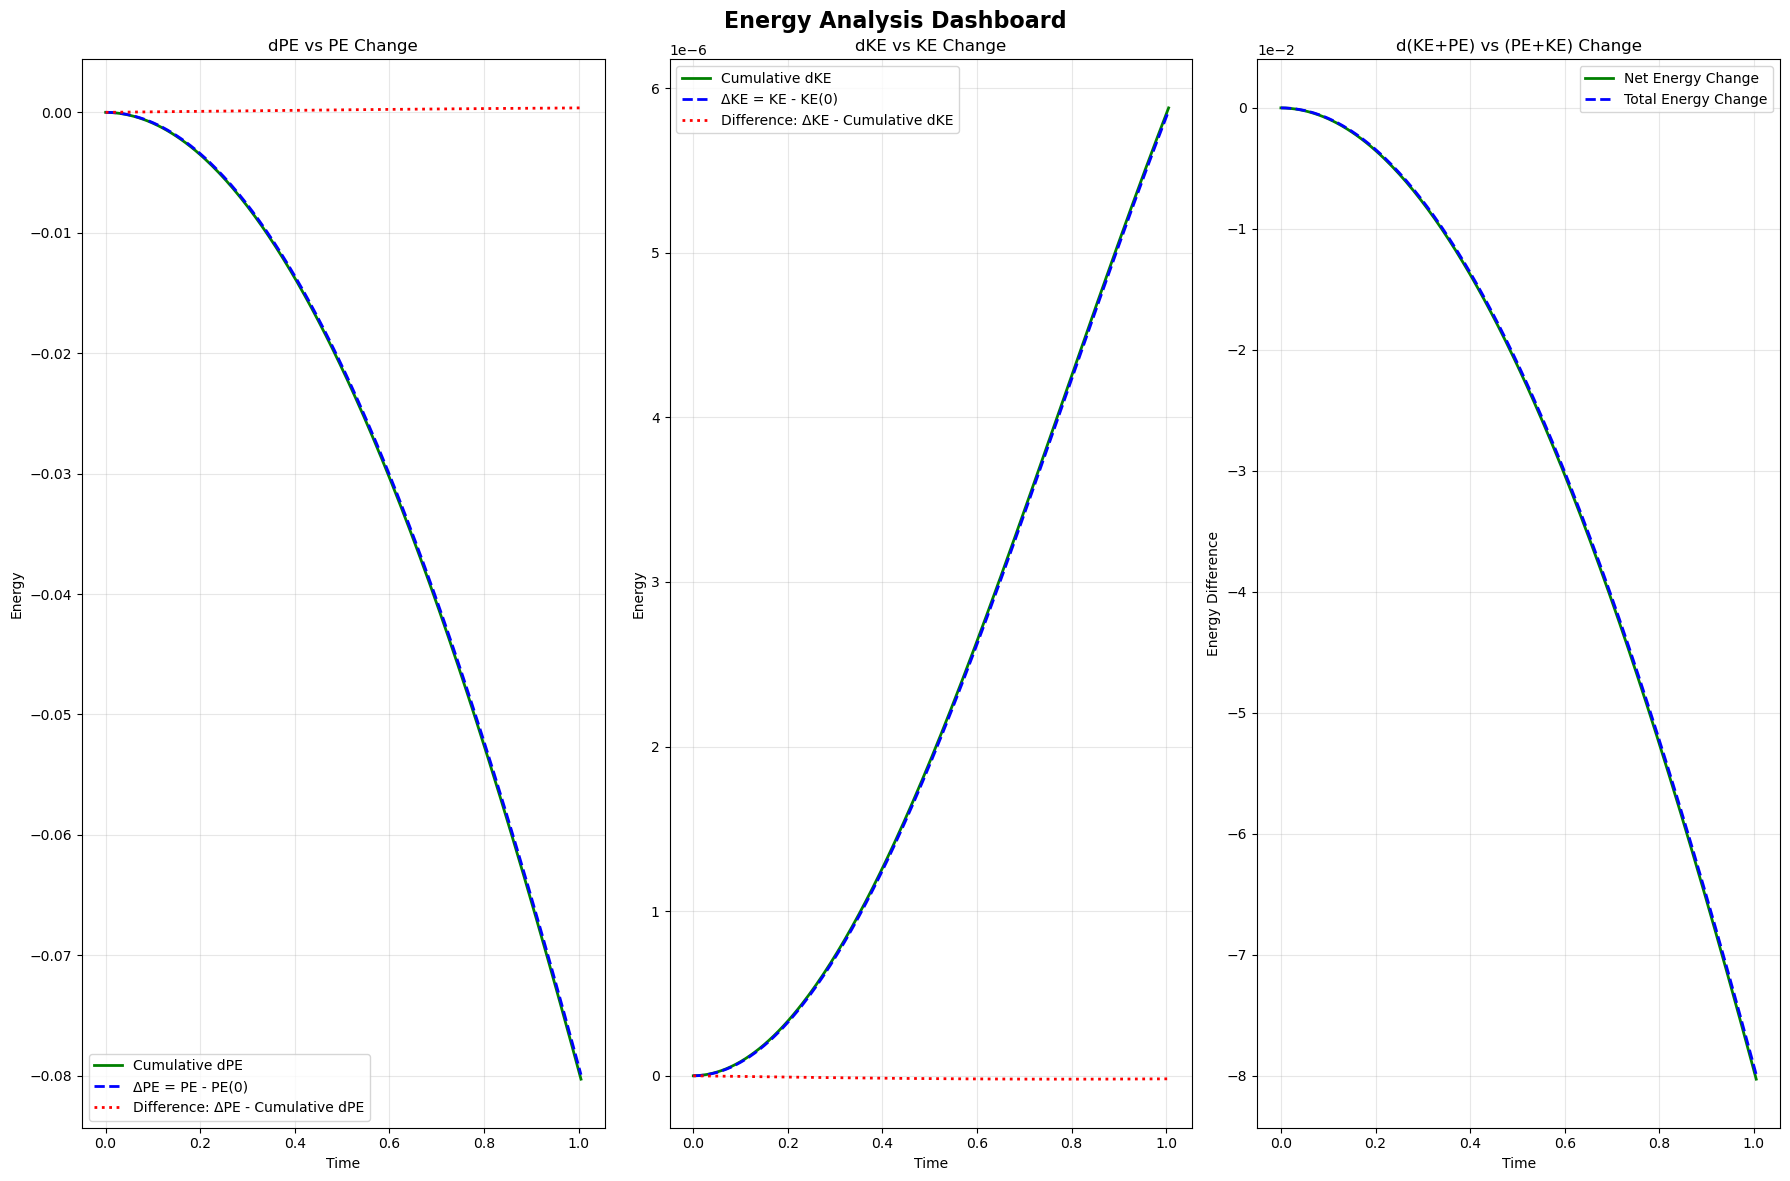


ENERGY ANALYSIS SUMMARY
Initial KE: 0.000000e+00
Final KE: 5.861056e-06
KE Change: 5.861056e-06
Cumulative dKE: 5.879556e-06
Residual (ΔKE - Cum.dKE): -1.849996e-08
Initial PE: 0.000000e+00
Final PE: -7.991361e-02
PE Change: -7.991361e-02
Cumulative dPE: -8.028203e-02
Residual (ΔPE - Cum.dPE): -1.849996e-08
Total Energy Change: -7.990775e-02
Cumulative d(KE+PE): -8.027615e-02
PE2 Change: -8.027615e-02
DETAILED ENERGY EVOLUTION TABLE
Total time steps: 202


,Time,KE,ΔKE,Cumul. dKE,KE Residual,PE,ΔPE,Cumul. dPE,PE Residual,Total Energy,PE2
0,0.0000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,0.0050,2.056168e-10,2.056168e-10,4.112284e-10,-2.056116e-10,-2.153206e-06,-2.153206e-06,-4.306839e-06,2.153632e-06,-2.153000e-06,-4.306427e-06
2,0.0100,8.224516e-10,8.224516e-10,1.233647e-09,-4.111950e-10,-8.612857e-06,-8.612857e-06,-1.292043e-05,4.307578e-06,-8.612035e-06,-1.291920e-05
3,0.0150,1.850443e-09,1.850443e-09,2.467172e-09,-6.167295e-10,-1.937879e-05,-1.937879e-05,-2.584057e-05,6.461780e-06,-1.937694e-05,-2.583811e-05
4,0.0200,3.289488e-09,3.289488e-09,4.111682e-09,-8.221946e-10,-3.445077e-05,-3.445077e-05,-4.306693e-05,8.616165e-06,-3.444748e-05,-4.306282e-05
5,0.0250,5.139442e-09,5.139442e-09,6.167012e-09,-1.027570e-09,-5.382839e-05,-5.382839e-05,-6.459908e-05,1.077069e-05,-5.382325e-05,-6.459291e-05
6,0.0300,7.400122e-09,7.400122e-09,8.632956e-09,-1.232835e-09,-7.751115e-05,-7.751115e-05,-9.043647e-05,1.292533e-05,-7.750375e-05,-9.042784e-05
7,0.0350,1.007130e-08,1.007130e-08,1.150927e-08,-1.437968e-09,-1.054985e-04,-1.054985e-04,-1.205785e-04,1.507999e-05,-1.054884e-04,-1.205670e-04
8,0.0400,1.315271e-08,1.315271e-08,1.479566e-08,-1.642950e-09,-1.377897e-04,-1.377897e-04,-1.550243e-04,1.723461e-05,-1.377766e-04,-1.550095e-04
9,0.0450,1.664404e-08,1.664404e-08,1.849180e-08,-1.847761e-09,-1.743840e-04,-1.743840e-04,-1.937732e-04,1.938916e-05,-1.743674e-04,-1.937547e-04


In [ ]:
# read especData.dat in the output
import numpy as np
import pandas as pd
from IPython.display import display, HTML
import matplotlib.pyplot as plt

# Load the data from the file
with open('../../output/especData.dat', 'r') as f:
    lines = f.readlines()

# Process the data
i = 0
times = []
ke_data = []
pe_data = []
pe2_data = []
dke_data = []
has_pe2 = False
while i < len(lines):

    current_set = {}
    set_start = i
    
    while i < len(lines):
        line = lines[i].strip()
        if line:
            parts = line.split()
            label = parts[0].rstrip(':').upper()
            time_val = float(parts[1])
            data_vals = [float(x) for x in parts[2:]]
            
            current_set[label] = {'time': time_val, 'data': data_vals}
            i += 1
            
            # Check if we have a complete set (at minimum KE, PE, DKE)
            if 'KE' in current_set and 'PE' in current_set and 'DKE' in current_set:
                # Check if there's a PE2 in the next line
                if i < len(lines):
                    next_line = lines[i].strip()
                    if next_line and next_line.split()[0].rstrip(':').upper() == 'PE2':
                        continue  # Read PE2 as well
                break
        else:
            i += 1
    
    # Store the data from current set
    if 'KE' in current_set and 'PE' in current_set and 'DKE' in current_set:
        times.append(current_set['KE']['time'])
        ke_data.append(current_set['KE']['data'])
        pe_data.append(current_set['PE']['data'])
        dke_data.append(current_set['DKE']['data'])
        
        # Check for PE2
        if 'PE2' in current_set:
            pe2_data.append(current_set['PE2']['data'])
            has_pe2 = True
        elif has_pe2:  # If we had PE2 before but not now, pad with zeros
            pe2_data.append([0.0] * len(current_set['PE']['data']))

ke_data = np.array(ke_data)
pe_data = np.array(pe_data)
dke_data = np.array(dke_data)
times = np.array(times)

if has_pe2:
    pe2_data = np.array(pe2_data)

# Calculate total energy
total_ke = np.sum(ke_data, axis=1)*0.5
total_pe = np.sum(pe_data, axis=1)
total_pe = total_pe - total_pe[0]  # Normalize potential energy

total_energy = total_ke + total_pe

# Calculate time step sizes and integrate dKE properly
time_steps = np.diff(times)
time_steps = np.append(time_steps[0], time_steps)  # Use first time step for initial value
total_dke_per_step = np.sum(dke_data, axis=1) * time_steps
total_dke = np.cumsum(total_dke_per_step)
if has_pe2:
    total_pe2_per_step = np.sum(pe2_data, axis=1) * time_steps
    total_pe2 = np.cumsum(total_pe2_per_step)
    total_dpe = -total_dke+total_pe2

# Print information about detected data
print(f"Detected data types: KE, PE, DKE", end="")
if has_pe2:
    print(", PE2")
else:
    print()
print(f"Number of time steps: {len(times)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 12))
fig.suptitle('Energy Analysis Dashboard', fontsize=16, fontweight='bold')

# 1. Energy Evolution Over Time
# ax1 = axes[0]
# ax1.plot(times, total_ke, label='Kinetic Energy (KE)', linestyle='-', linewidth=2, color='blue')
# # ax1.plot(times, total_pe, label='Potential Energy (PE)', linestyle='-', linewidth=2, color='red')
# ax1.plot(times, total_energy, label='Total Energy (KE + PE)', linestyle='--', linewidth=2, color='black')
# ax1.set_xlabel('Time')
# ax1.set_ylabel('Energy')
# ax1.set_title('Energy Evolution Over Time')
# ax1.legend()
# ax1.grid(True, alpha=0.3)

# 1. dPE Analysis
ax1 = axes[0]
ax1.plot(times, total_dpe, label='Cumulative dPE', linestyle='-', linewidth=2, color='green')
ax1.plot(times, total_pe-total_pe[0], label='ΔPE = PE - PE(0)', linestyle='--', linewidth=2, color='blue')
difference = (total_pe - total_pe[0]) - total_dpe
ax1.plot(times, difference, label='Difference: ΔPE - Cumulative dPE', linestyle=':', linewidth=2, color='red')
ax1.set_xlabel('Time')
ax1.set_ylabel('Energy')
ax1.set_title('dPE vs PE Change')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. dKE Analysis
ax2 = axes[1]
ax2.plot(times, total_dke, label='Cumulative dKE', linestyle='-', linewidth=2, color='green')
ax2.plot(times, total_ke-total_ke[0], label='ΔKE = KE - KE(0)', linestyle='--', linewidth=2, color='blue')
difference = (total_ke - total_ke[0]) - total_dke
ax2.plot(times, difference, label='Difference: ΔKE - Cumulative dKE', linestyle=':', linewidth=2, color='red')
ax2.set_xlabel('Time')
ax2.set_ylabel('Energy')
ax2.set_title('dKE vs KE Change')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Total energy
ax3 = axes[2]
ax3.plot(times, total_dpe+total_dke, label='Net Energy Change', linestyle='-', linewidth=2, color='green')
ax3.plot(times,total_pe-total_pe[0]+total_ke-total_ke[0], label='Total Energy Change', linestyle='--', linewidth=2, color='blue')
ax3.set_xlabel('Time')
ax3.set_ylabel('Energy Difference')
ax3.set_title('d(KE+PE) vs (PE+KE) Change')
ax3.grid(True, alpha=0.3)
ax3.legend()
ax3.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.show()

# Time stamp table
detailed_data = []
for i, t in enumerate(times):
    row = {
        'Time': f'{t:.4f}',
        'KE': f'{total_ke[i]:.6e}',
        'ΔKE': f'{total_ke[i] - total_ke[0]:.6e}',
        'Cumul. dKE': f'{total_dke[i]:.6e}',
        'KE Residual': f'{(total_ke[i] - total_ke[0]) - total_dke[i]:.6e}',
        'PE': f'{total_pe[i]:.6e}',
        'ΔPE': f'{total_pe[i] - total_pe[0]:.6e}',
        'Cumul. dPE': f'{total_dpe[i]:.6e}',
        'PE Residual': f'{(total_pe[i] - total_pe[0]) - total_dpe[i]:.6e}',
        'Total Energy Change': f'{(total_energy[i] - total_energy[0]):.6e}',
    }
    if has_pe2:
        row['Net cum dPE+dKE'] = f'{(total_pe2[i] - total_pe2[0]):.6e}'
    detailed_data.append(row)

df = pd.DataFrame(detailed_data)

styled_df = df.style.set_properties(**{
    'text-align': 'center',
    'font-size': '10px'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#40466e'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('border', '1px solid #ddd')]},
    {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', '100%')]}
])

print("\n" + "="*60)
print("ENERGY ANALYSIS SUMMARY")
print("="*60)
print(f"Initial KE: {total_ke[0]:.6e}")
print(f"Final KE: {total_ke[-1]:.6e}")
print(f"KE Change: {total_ke[-1] - total_ke[0]:.6e}")
print(f"Cumulative dKE: {total_dke[-1]:.6e}")
print(f"Residual (ΔKE - Cum.dKE): {difference[-1]:.6e}")
print(f"Initial PE: {total_pe[0]:.6e}")
print(f"Final PE: {total_pe[-1]:.6e}")
print(f"PE Change: {total_pe[-1] - total_pe[0]:.6e}")
print(f"Cumulative dPE: {total_dpe[-1]:.6e}")
print(f"Residual (ΔPE - Cum.dPE): {difference[-1]:.6e}")
print(f"Total Energy Change: {total_energy[-1] - total_energy[0]:.6e}")
print(f"Cumulative d(KE+PE): {total_dke[-1] + total_dpe[-1]:.6e}")
if has_pe2:
    print(f"PE2 Change: {total_pe2[-1] - total_pe2[0]:.6e}")
print("="*60)
print("DETAILED ENERGY EVOLUTION TABLE")
print("="*60)
print(f"Total time steps: {len(times)}")
display(styled_df)